<a href="https://colab.research.google.com/github/cacciella/PythonProEstudos/blob/master/Mini_Projeto_Semana_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Mini Projeto Semana 1
###Vaga Data Science


In [ ]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Dados_DS/Financial Sample.xlsx')

In [ ]:
df.head(1)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.50,3,20,32370.00,0.00,32370.00,16185.00,16185.00,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.00,3,20,26420.00,0.00,26420.00,13210.00,13210.00,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.00,3,15,32670.00,0.00,32670.00,21780.00,10890.00,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.00,3,15,13320.00,0.00,13320.00,8880.00,4440.00,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.00,3,15,37050.00,0.00,37050.00,24700.00,12350.00,2014-06-01,6,June,2014


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9   Sales                700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [ ]:
df = df.rename(columns = {' Sales': 'Sales'})

In [ ]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700,700.00,700.00
mean,1608.29,96.48,118.43,182759.43,13150.35,169609.07,145475.21,24133.86,2014-04-28 21:36:00,7.90,2013.75
min,200.00,3.00,7.00,1799.00,0.00,1655.08,918.00,-40617.50,2013-09-01 00:00:00,1.00,2013.00
25%,905.00,5.00,12.00,17391.75,800.32,15928.00,7490.00,2805.96,2013-12-24 06:00:00,5.75,2013.75
50%,1542.50,10.00,20.00,37980.00,2585.25,35540.20,22506.25,9242.20,2014-05-16 12:00:00,9.00,2014.00
75%,2229.12,250.00,300.00,279025.00,15956.34,261077.50,245607.50,22662.00,2014-09-08 12:00:00,10.25,2014.00
max,4492.50,260.00,350.00,1207500.00,149677.50,1159200.00,950625.00,262200.00,2014-12-01 00:00:00,12.00,2014.00
std,867.43,108.60,136.78,254262.28,22962.93,236726.35,203865.51,42760.63,NaN,3.38,0.43


##Analise:

1. *Soma* total de vendas
1. O menor valor
1. O maior valor de vendas
1. A media das vendas

In [ ]:
df['Sales'].agg(["sum", "min", "max", "mean"])

,Sales
sum,118726350.26
min,1655.08
max,1159200.00
mean,169609.07


In [ ]:
# o produto mais vendido, por ordem de mais vendido
#Units Sold  Product

df.groupby('Product')['Units Sold'].sum().reset_index().sort_values(by='Units Sold', ascending=False)

,Product,Units Sold
3,Paseo,338239.50
4,VTT,168783.00
5,Velo,162424.50
0,Amarilla,155315.00
2,Montana,154198.00
1,Carretera,146846.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vendas_produto = (df.groupby('Product')['Units Sold'].sum().reset_index().sort_values(by='Units Sold', ascending=False)
)

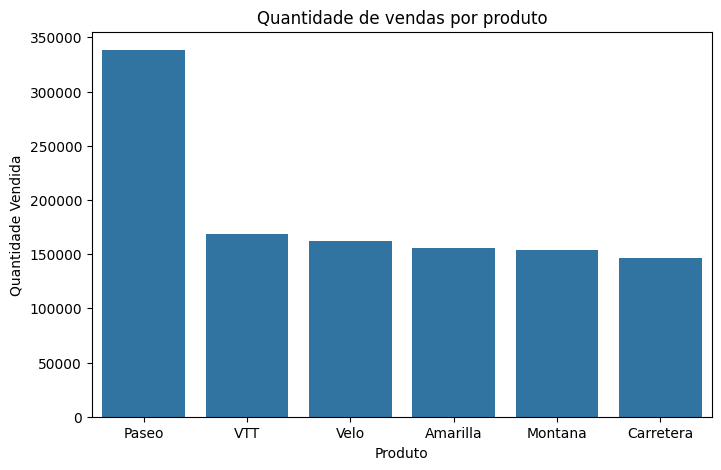

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=vendas_produto,
    x='Product',
    y='Units Sold'
)

plt.title('Quantidade de vendas por produto')
plt.xlabel('Produto')
plt.ylabel('Quantidade Vendida')

plt.show()

#Quantidades de Vendas por produtos

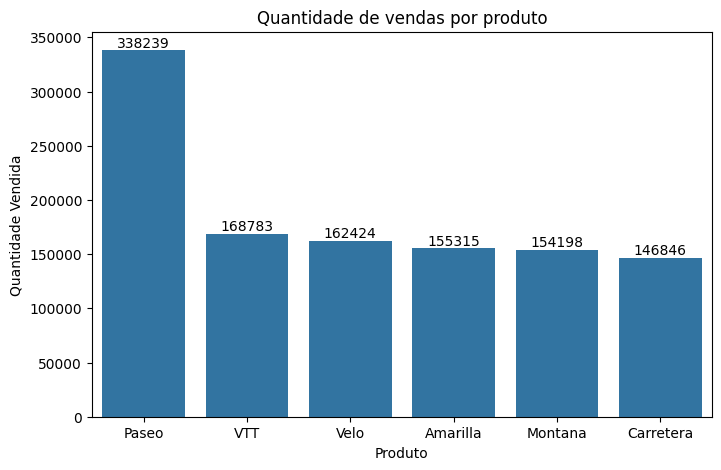

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=vendas_produto,
    x='Product',
    y='Units Sold'
)

for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(
        f'{int(altura)}',
        (barra.get_x() + barra.get_width()/2, altura),
        ha='center',
        va='bottom'
    )

plt.title('Quantidade de vendas por produto')
plt.xlabel('Produto')
plt.ylabel('Quantidade Vendida')

plt.show()

In [ ]:
df.groupby('Product')['Product'].count()

,Product
Product,
Amarilla,94
Carretera,93
Montana,93
Paseo,202
VTT,109
Velo,109


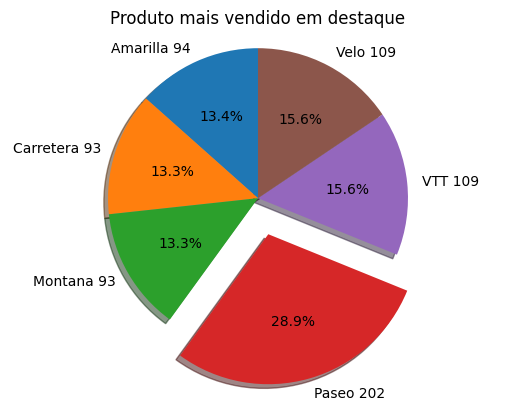

In [ ]:
import matplotlib.pyplot as plt

labels = 'Amarilla 94', 'Carretera 93', 'Montana 93', 'Paseo 202', 'VTT 109', 'Velo 109'
sizes = [94, 93, 93, 202, 109, 109]
explode = (0, 0, 0, 0.25, 0, 0)

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')

plt.title('Produto mais vendido em destaque')
plt.show()

#Maior por segmento

In [ ]:
df.groupby('Segment')['Segment'].count()

,Segment
Segment,
Channel Partners,100
Enterprise,100
Government,300
Midmarket,100
Small Business,100


In [ ]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.50,3,20,32370.00,0.00,32370.00,16185.00,16185.00,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.00,3,20,26420.00,0.00,26420.00,13210.00,13210.00,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.00,3,15,32670.00,0.00,32670.00,21780.00,10890.00,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.00,3,15,13320.00,0.00,13320.00,8880.00,4440.00,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.00,3,15,37050.00,0.00,37050.00,24700.00,12350.00,2014-06-01,6,June,2014


Calculo do valor total

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Converter 'Product' de texto para numeros.
le = LabelEncoder()
df['Product'] = le.fit_transform(df['Product'])

In [ ]:
df['Valor_Total'] = df['Product'] * df['Sale Price']

In [ ]:
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Valor_Total
0,Government,Canada,1,NaN,1618.50,3,20,32370.00,0.00,32370.00,16185.00,16185.00,2014-01-01,1,January,2014,20
1,Government,Germany,1,NaN,1321.00,3,20,26420.00,0.00,26420.00,13210.00,13210.00,2014-01-01,1,January,2014,20
2,Midmarket,France,1,NaN,2178.00,3,15,32670.00,0.00,32670.00,21780.00,10890.00,2014-06-01,6,June,2014,15
3,Midmarket,Germany,1,NaN,888.00,3,15,13320.00,0.00,13320.00,8880.00,4440.00,2014-06-01,6,June,2014,15
4,Midmarket,Mexico,1,NaN,2470.00,3,15,37050.00,0.00,37050.00,24700.00,12350.00,2014-06-01,6,June,2014,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,0,High,2475.00,260,300,742500.00,111375.00,631125.00,618750.00,12375.00,2014-03-01,3,March,2014,0
696,Small Business,Mexico,0,High,546.00,260,300,163800.00,24570.00,139230.00,136500.00,2730.00,2014-10-01,10,October,2014,0
697,Government,Mexico,2,High,1368.00,5,7,9576.00,1436.40,8139.60,6840.00,1299.60,2014-02-01,2,February,2014,14
698,Government,Canada,3,High,723.00,10,7,5061.00,759.15,4301.85,3615.00,686.85,2014-04-01,4,April,2014,21


#Faturamento por produto

In [ ]:
faturamento = (df
               .groupby('Product')['Valor_Total']
               .sum()
               .reset_index()
               .sort_values('Valor_Total', ascending=False))

faturamento

,Product,Valor_Total
3,3,65556
5,5,62805
4,4,60424
2,2,21780
1,1,10395
0,0,0


#Faturamento

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

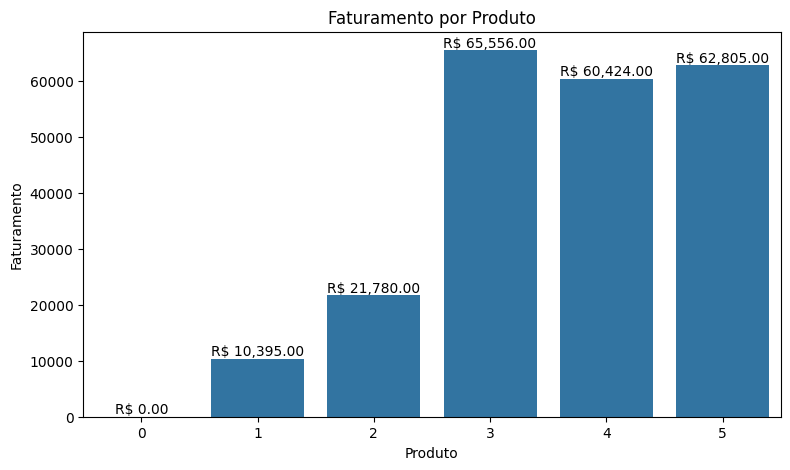

In [ ]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=faturamento,
    x='Product',
    y='Valor_Total'
)

for barra in ax.patches:
    ax.annotate(
        f'R$ {barra.get_height():,.2f}',
        (barra.get_x()+barra.get_width()/2,
         barra.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Faturamento por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento')

plt.show()

#Descobrindo o Top 3 produtos

In [ ]:
top3 = faturamento.nlargest(3, 'Valor_Total')

print(top3)

   Product  Valor_Total
3        3        65556
5        5        62805
4        4        60424


#Ticket médio por pedido

In [ ]:
ticket_medio = df['Valor_Total'].mean()

print(f'Ticket médio: R$ {ticket_medio:.2f}')

Ticket médio: R$ 315.66


###Ticket médio: R$ 315.66

In [ ]:
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Valor_Total
0,Government,Canada,1,NaN,1618.50,3,20,32370.00,0.00,32370.00,16185.00,16185.00,2014-01-01,1,January,2014,20
1,Government,Germany,1,NaN,1321.00,3,20,26420.00,0.00,26420.00,13210.00,13210.00,2014-01-01,1,January,2014,20
2,Midmarket,France,1,NaN,2178.00,3,15,32670.00,0.00,32670.00,21780.00,10890.00,2014-06-01,6,June,2014,15
3,Midmarket,Germany,1,NaN,888.00,3,15,13320.00,0.00,13320.00,8880.00,4440.00,2014-06-01,6,June,2014,15
4,Midmarket,Mexico,1,NaN,2470.00,3,15,37050.00,0.00,37050.00,24700.00,12350.00,2014-06-01,6,June,2014,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,0,High,2475.00,260,300,742500.00,111375.00,631125.00,618750.00,12375.00,2014-03-01,3,March,2014,0
696,Small Business,Mexico,0,High,546.00,260,300,163800.00,24570.00,139230.00,136500.00,2730.00,2014-10-01,10,October,2014,0
697,Government,Mexico,2,High,1368.00,5,7,9576.00,1436.40,8139.60,6840.00,1299.60,2014-02-01,2,February,2014,14
698,Government,Canada,3,High,723.00,10,7,5061.00,759.15,4301.85,3615.00,686.85,2014-04-01,4,April,2014,21


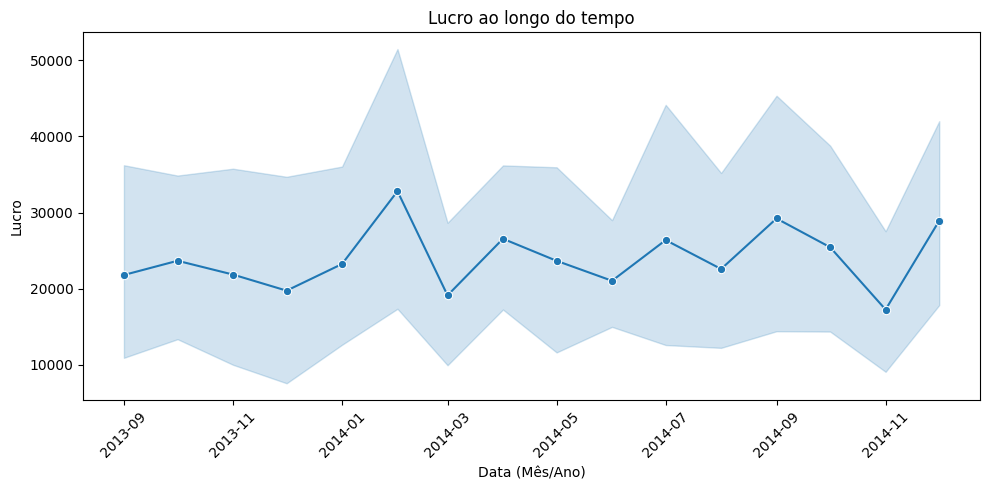

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="Date", y="Profit", marker="o")

plt.title("Lucro ao longo do tempo")
plt.xlabel("Data (Mês/Ano)")
plt.ylabel("Lucro")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Resumo

In [ ]:
print(f'Número de pedidos: {df["Sales"].nunique()}')

Número de pedidos: 559


In [ ]:
print(f'Quantidade total vendida: {df["Sales"].sum():,.2f}')

Quantidade total vendida: 118,726,350.26


In [ ]:
print(f'Faturamento total: R$ {df["Valor_Total"].sum():,.2f}')

Faturamento total: R$ 220,960.00


In [ ]:
print(f'Ticket médio: R$ {df["Valor_Total"].mean():,.2f}')

Ticket médio: R$ 315.66


In [ ]:
print(f'Número de clientes por segmento: {df["Segment"].nunique()}')

Número de clientes por segmento: 5
